Model Accuracy: 1.0


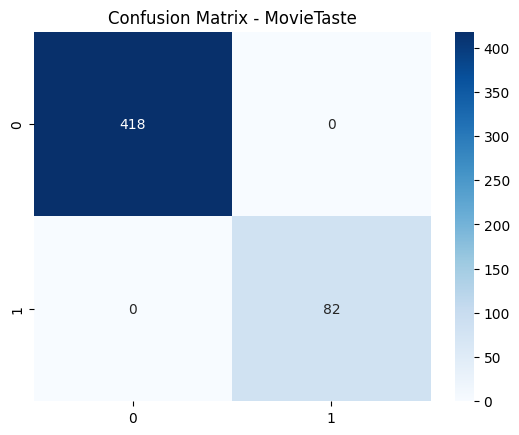

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       418
           1       1.00      1.00      1.00        82

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



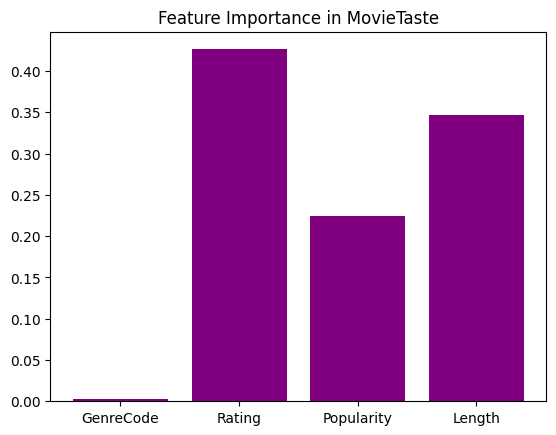

User will LIKE this movie 🎬
User will NOT like this movie 💔


In [14]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Generate Synthetic Movie Dataset (2500 movies)
np.random.seed(42)
rows = 2500

data = pd.DataFrame({
    "Genre": np.random.choice(["Action","Comedy","Drama","Sci-Fi","Romance"], rows),
    "Rating": np.random.uniform(1, 5, rows),            # IMDb style rating
    "Popularity": np.random.randint(100, 10000, rows),  # Number of viewers
    "Length": np.random.randint(80, 180, rows)          # Movie length in minutes
})

# Encode Genre
data["GenreCode"] = data["Genre"].map({
    "Action":1,"Comedy":2,"Drama":3,"Sci-Fi":4,"Romance":5
})

# Target column: Like (1 = User will like, 0 = User will not like)
data["Like"] = np.where(
    (data["Rating"] > 3.5) & (data["Popularity"] > 3000) & (data["Length"].between(90,150)), 1, 0
)

# Step 3: Features & Target
X = data[["GenreCode","Rating","Popularity","Length"]]
y = data["Like"]

# Step 4: Split Data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Step 5: Train Model (Random Forest)
model = RandomForestClassifier(n_estimators=120,random_state=42)
model.fit(X_train,y_train)

# Step 6: Predictions
predictions = model.predict(X_test)

# Step 7: Accuracy
print("Model Accuracy:", accuracy_score(y_test,predictions))

# Step 8: Confusion Matrix
cm = confusion_matrix(y_test,predictions)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix - MovieTaste")
plt.show()

# Step 9: Classification Report
print(classification_report(y_test,predictions))

# Step 10: Feature Importance (Visual Output)
importance = model.feature_importances_
plt.bar(X.columns, importance, color="purple")
plt.title("Feature Importance in MovieTaste")
plt.show()

# Step 11: Custom Prediction Function
def predict_like(genre,rating,popularity,length):
    input_data = pd.DataFrame([[genre,rating,popularity,length]],
                              columns=["GenreCode","Rating","Popularity","Length"])
    prediction = model.predict(input_data)
    return "User will LIKE this movie 🎬" if prediction[0]==1 else "User will NOT like this movie 💔"

# Example Predictions
print(predict_like(1,4.2,8000,120))   # Action movie, high rating
print(predict_like(3,2.5,1500,170))   # Drama movie, low rating
